In [1]:
# If you do not use colab. You should install these packages.
# !pip install numpy
# !pip install pandas
# !pip install matplotlib
# !pip install scikit-learn
# !pip install graphviz

In [2]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

In [3]:
from model.metrics import MSE, MAE, evaluate_linear_regression
from model.gradients import MSE_grad
#from model.gradients import MSE_grad, MAE_grad
from model.utils import *
import matplotlib.pyplot as plt

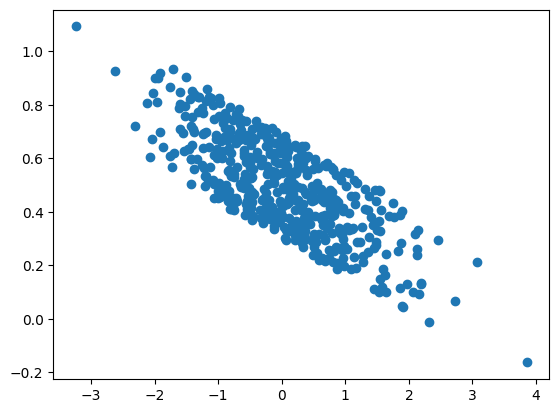

In [4]:
# Sample Code for generating datasets
seed=42
np.random.seed(seed)
size = 500
dim = 1
noise_bound = 0.2
X,y,W = generate_linear_dataset(size,dim,noise_bound=noise_bound,is_reg=True)
plt.scatter(X[:,1],y)

In [5]:
# Loading data
linear_data_A = np.load(f'data/linear_data/linear_data_A.npz')
linear_data_B = np.load(f'data/linear_data/linear_data_B.npz')
linear_data_C = np.load(f'data/linear_data/linear_data_C.npz')
linear_data_D = np.load(f'data/linear_data/linear_data_D.npz')

X_A = linear_data_A['X_data']
X_B = linear_data_B['X_data']
X_C = linear_data_C['X_data']
X_D = linear_data_D['X_data']

y_A = linear_data_A['y_data']
y_B = linear_data_B['y_data']
y_C = linear_data_C['y_data']
y_D = linear_data_D['y_data']

W_A = linear_data_A['W_data']
W_B = linear_data_B['W_data']
W_C = linear_data_C['W_data']
W_D = linear_data_D['W_data']

# Show the size of data
print(f"X_A size : {X_A.shape}, y_A size : {y_A.shape}")
print(f"X_B size : {X_B.shape}, y_B size : {y_B.shape}")
print(f"X_C size : {X_C.shape}, y_C size : {y_C.shape}")
print(f"X_D size : {X_D.shape}, y_D size : {y_D.shape}")

# Make sure size and dim correct.
size_A = X_A.shape[0]
size_B = X_B.shape[0]
size_C = X_C.shape[0]
size_D = X_D.shape[0]
dim_A = X_A.shape[1] - 1
dim_B = X_B.shape[1] - 1
dim_C = X_C.shape[1] - 1
dim_D = X_D.shape[1] - 1

X_A size : (1600, 2), y_A size : (1600,)
X_B size : (1600, 2), y_B size : (1600,)
X_C size : (8000, 6), y_C size : (8000,)
X_D size : (8000, 6), y_D size : (8000,)


50. Training loss: 0.013423623061455565, Val loss:0.012580010701461058
100. Training loss: 0.013423622480987135, Val loss:0.012580089713127157
150. Training loss: 0.013423622480987133, Val loss:0.012580089715050587
200. Training loss: 0.013423622480987133, Val loss:0.012580089715050636
250. Training loss: 0.013423622480987133, Val loss:0.012580089715050636
300. Training loss: 0.013423622480987133, Val loss:0.012580089715050636
350. Training loss: 0.013423622480987133, Val loss:0.012580089715050636
400. Training loss: 0.013423622480987133, Val loss:0.012580089715050636
450. Training loss: 0.013423622480987133, Val loss:0.012580089715050636
500. Training loss: 0.013423622480987133, Val loss:0.012580089715050636


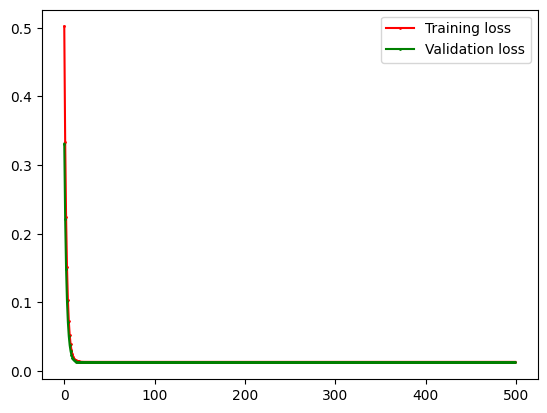

50. Training loss: 0.22389665936596015, Val loss:0.2222721701368548
100. Training loss: 0.04473791353662415, Val loss:0.043506871320832495
150. Training loss: 0.018083051477028683, Val loss:0.017079948707739195
200. Training loss: 0.014116985551358614, Val loss:0.013210362684918413
250. Training loss: 0.013526808616498798, Val loss:0.012658557107672769
300. Training loss: 0.013438979611857652, Val loss:0.012585780449882416
350. Training loss: 0.013425908200894933, Val loss:0.01257859777405428
400. Training loss: 0.013423962698572107, Val loss:0.012578954541903343
450. Training loss: 0.013423673122704472, Val loss:0.012579564566392844
500. Training loss: 0.013423630019323562, Val loss:0.012579872725242275


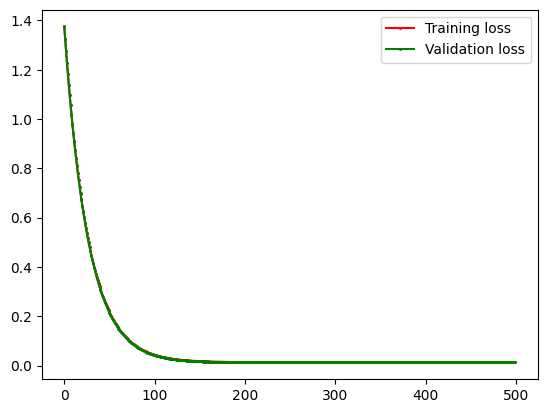

50. Training loss: 0.8073193599304311, Val loss:0.8241529476258102
100. Training loss: 0.6707081465060073, Val loss:0.6842801553483973
150. Training loss: 0.5576046128976588, Val loss:0.5684953729365146
200. Training loss: 0.46396361719496254, Val loss:0.4726520096184924
250. Training loss: 0.38643609623660424, Val loss:0.3933171293112558
300. Training loss: 0.32224928579205103, Val loss:0.3276486400150125
350. Training loss: 0.2691075522448654, Val loss:0.2732936160341767
400. Training loss: 0.22511028898031432, Val loss:0.22830411667665368
450. Training loss: 0.1886839410088189, Val loss:0.19106749078309526
500. Training loss: 0.15852572666075965, Val loss:0.16024867447531232


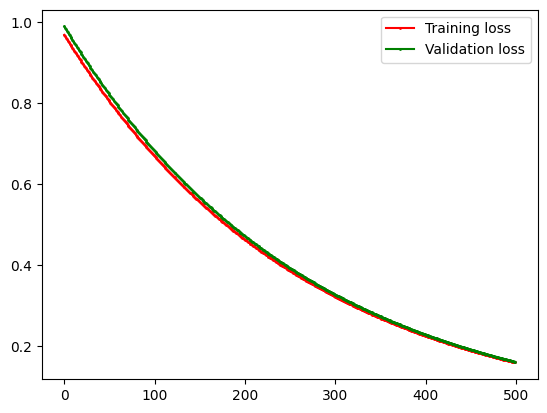

50. Training loss: 0.21477796066883237, Val loss:0.20128109890861165
100. Training loss: 0.2147779596957941, Val loss:0.201281435431671
150. Training loss: 0.21477795969579408, Val loss:0.2012814354408099
200. Training loss: 0.21477795969579408, Val loss:0.20128143544081017
250. Training loss: 0.21477795969579408, Val loss:0.20128143544081017
300. Training loss: 0.21477795969579408, Val loss:0.20128143544081017
350. Training loss: 0.21477795969579408, Val loss:0.20128143544081017
400. Training loss: 0.21477795969579408, Val loss:0.20128143544081017
450. Training loss: 0.21477795969579408, Val loss:0.20128143544081017
500. Training loss: 0.21477795969579408, Val loss:0.20128143544081017


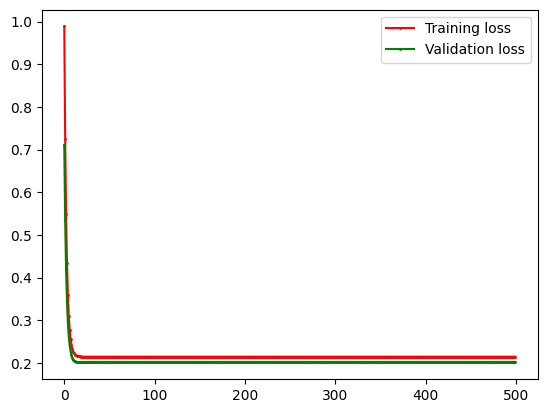

50. Training loss: 0.26464909148597293, Val loss:0.2422801458760765
100. Training loss: 0.2219683105059097, Val loss:0.20577799418047066
150. Training loss: 0.21581843751586055, Val loss:0.20140923616105855
200. Training loss: 0.21492902209599776, Val loss:0.2011069160516648
250. Training loss: 0.21479995771393334, Val loss:0.2011846943897838
300. Training loss: 0.21478117175217534, Val loss:0.2012409298478433
350. Training loss: 0.21477842984046402, Val loss:0.20126573660259128
400. Training loss: 0.21477802865836887, Val loss:0.2012755087480249
450. Training loss: 0.21477796983077477, Val loss:0.20127921816253902
500. Training loss: 0.21477796118777429, Val loss:0.2012806081249538


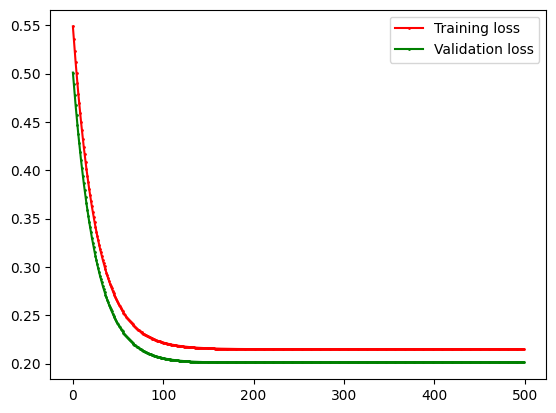

50. Training loss: 0.4913616832965255, Val loss:0.4572827778647196
100. Training loss: 0.4429266192230921, Val loss:0.4112159724891501
150. Training loss: 0.4029811292093255, Val loss:0.37333847064173414
200. Training loss: 0.37003579319083046, Val loss:0.3422029845430457
250. Training loss: 0.34286274783774906, Val loss:0.3166173336333146
300. Training loss: 0.3204497092307371, Val loss:0.29559951856347993
350. Training loss: 0.30196208578201933, Val loss:0.27834070713267195
400. Training loss: 0.28671175635065316, Val loss:0.2641747380515128
450. Training loss: 0.27413133978207394, Val loss:0.25255299426187505
500. Training loss: 0.26375298902633826, Val loss:0.24302369999692852


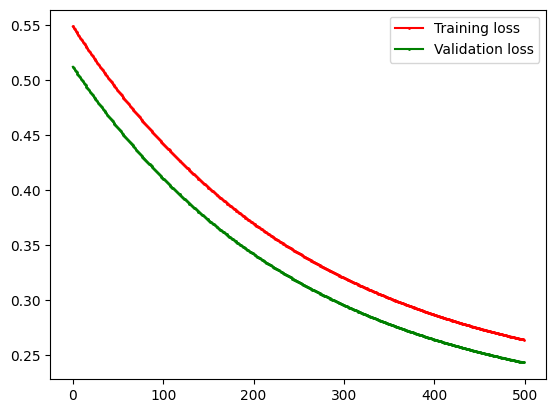

50. Training loss: 0.013181897126955286, Val loss:0.013771693021007596
100. Training loss: 0.013181896123422132, Val loss:0.013771595670608972
150. Training loss: 0.013181896123422132, Val loss:0.013771595669175333
200. Training loss: 0.013181896123422132, Val loss:0.013771595669175313
250. Training loss: 0.013181896123422132, Val loss:0.013771595669175313
300. Training loss: 0.013181896123422132, Val loss:0.013771595669175313
350. Training loss: 0.013181896123422132, Val loss:0.013771595669175313
400. Training loss: 0.013181896123422132, Val loss:0.013771595669175313
450. Training loss: 0.013181896123422132, Val loss:0.013771595669175313
500. Training loss: 0.013181896123422132, Val loss:0.013771595669175313


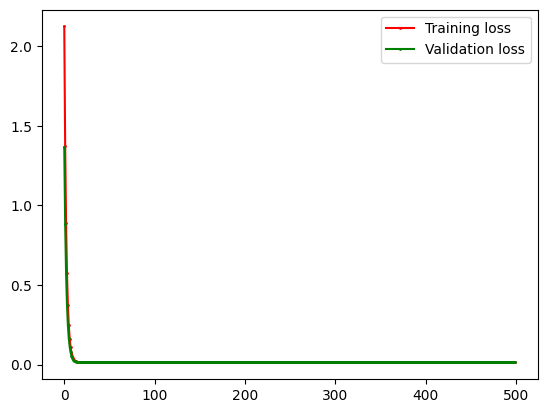

50. Training loss: 0.5063490066478714, Val loss:0.500972111616331
100. Training loss: 0.07895331880026098, Val loss:0.07929059516457262
150. Training loss: 0.021990732300560183, Val loss:0.022690085638355034
200. Training loss: 0.014366367675799107, Val loss:0.01501587662629197
250. Training loss: 0.013341756450857145, Val loss:0.013954904342443005
300. Training loss: 0.013203545857360045, Val loss:0.013801844053448215
350. Training loss: 0.013184837485953357, Val loss:0.013777642414536375
400. Training loss: 0.01318229691715433, Val loss:0.013773115196018643
450. Training loss: 0.013181950883859378, Val loss:0.013772053692444714
500. Training loss: 0.013181903623910099, Val loss:0.013771748696472125


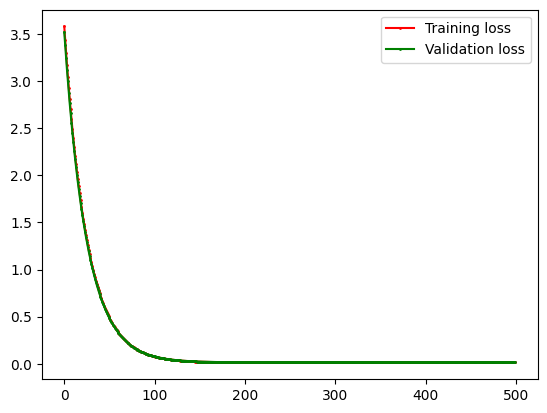

50. Training loss: 2.2017451404642507, Val loss:2.1960124930846896
100. Training loss: 1.7998164816338846, Val loss:1.7966940168478416
150. Training loss: 1.4717989196203543, Val loss:1.470584649802167
200. Training loss: 1.204083036407607, Val loss:1.2042408378797262
250. Training loss: 0.9855686166698512, Val loss:0.9866913128789381
300. Training loss: 0.8072014207162119, Val loss:0.8089818094140862
350. Training loss: 0.6615955839876154, Val loss:0.663803735694145
400. Training loss: 0.5427257951776887, Val loss:0.5451912970717979
450. Training loss: 0.44567634187380295, Val loss:0.4482744370193828
500. Training loss: 0.3664365045400647, Val loss:0.36907729545227275


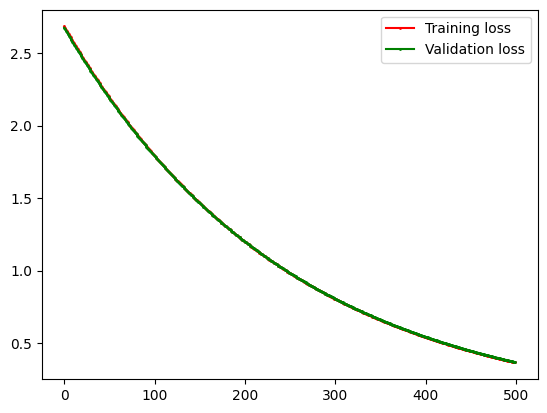

50. Training loss: 0.08238685189267729, Val loss:0.08607272912905756
100. Training loss: 0.08238685077138833, Val loss:0.08607247293613877
150. Training loss: 0.08238685077138833, Val loss:0.08607247293234575
200. Training loss: 0.08238685077138833, Val loss:0.0860724729323457
250. Training loss: 0.08238685077138833, Val loss:0.0860724729323457
300. Training loss: 0.08238685077138833, Val loss:0.0860724729323457
350. Training loss: 0.08238685077138833, Val loss:0.0860724729323457
400. Training loss: 0.08238685077138833, Val loss:0.0860724729323457
450. Training loss: 0.08238685077138833, Val loss:0.0860724729323457
500. Training loss: 0.08238685077138833, Val loss:0.0860724729323457


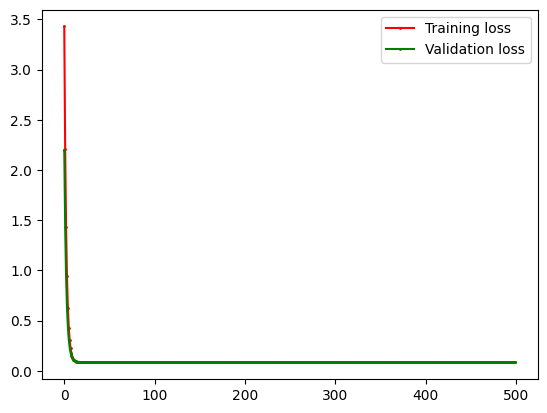

50. Training loss: 0.35772471842275805, Val loss:0.3573933191486517
100. Training loss: 0.11787423485933952, Val loss:0.12247259865689726
150. Training loss: 0.08699180403420656, Val loss:0.09126436160806282
200. Training loss: 0.08298840967382742, Val loss:0.08691284885403175
250. Training loss: 0.08246594719129074, Val loss:0.08624033011324964
300. Training loss: 0.0823973161406011, Val loss:0.08611515192706332
350. Training loss: 0.08238824373222911, Val loss:0.08608548727511353
400. Training loss: 0.08238703721926029, Val loss:0.08607684832316179
450. Training loss: 0.08238687585809601, Val loss:0.08607400887132353
500. Training loss: 0.08238685416313203, Val loss:0.08607302181781548


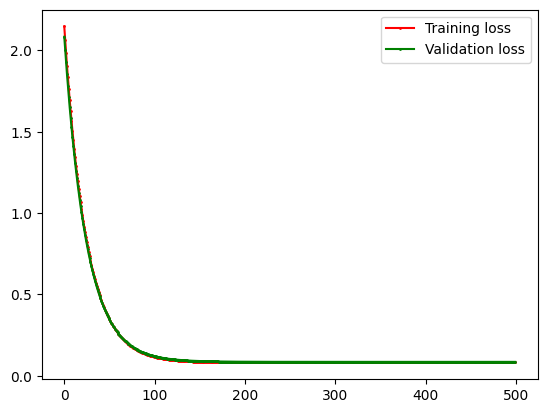

50. Training loss: 2.977842091849678, Val loss:2.991178630940394
100. Training loss: 2.4530500271915923, Val loss:2.4667946660701956
150. Training loss: 2.0235225451749654, Val loss:2.0372948541688096
200. Training loss: 1.6719392794934964, Val loss:1.6854756448316421
250. Training loss: 1.3841339239972679, Val loss:1.397258335010949
300. Training loss: 1.1485189592797662, Val loss:1.1611205082912432
350. Training loss: 0.9556154719214216, Val loss:0.9676310925714681
400. Training loss: 0.7976688370395155, Val loss:0.8090701216162944
450. Training loss: 0.6683345589051146, Val loss:0.679117744104588
500. Training loss: 0.562421441618319, Val loss:0.5725998487090962


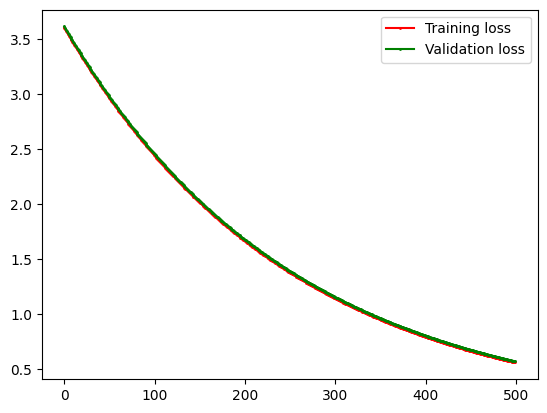

In [6]:
# Train the model
from model.linear_model import LinearModel

seed = 42 # do not change the seed
np.random.seed(seed)

# Setting loss function and gradient. 
loss_fn = MSE
grad_fn = MSE_grad

# Split dataset to train dataset and validation dataset
X_train_A,y_train_A,X_val_A,y_val_A = get_train_val(X_A,y_A)
X_train_B,y_train_B,X_val_B,y_val_B = get_train_val(X_B,y_B)
X_train_C,y_train_C,X_val_C,y_val_C = get_train_val(X_C,y_C)
X_train_D,y_train_D,X_val_D,y_val_D = get_train_val(X_D,y_D)

# Setting model and starting training

learning_rates = [0.1, 0.01, 0.001]

models_A = []
models_B = []
models_C = []
models_D = []

for lr in learning_rates:
  model = LinearModel(dim_A,True,loss_fn,grad_fn)
  model.fit(X_train_A,y_train_A,lr=lr,n_iteration =500,val_ratio=0.2)
  models_A.append(model)

for lr in learning_rates:
  model = LinearModel(dim_B,True,loss_fn,grad_fn)
  model.fit(X_train_B,y_train_B,lr=lr,n_iteration =500,val_ratio=0.2)
  models_B.append(model)


for lr in learning_rates:
  model = LinearModel(dim_C,True,loss_fn,grad_fn)
  model.fit(X_train_C,y_train_C,lr=lr,n_iteration =500,val_ratio=0.2)
  models_C.append(model)
  
for lr in learning_rates:
  model = LinearModel(dim_D,True,loss_fn,grad_fn)
  model.fit(X_train_D,y_train_D,lr=lr,n_iteration =500,val_ratio=0.2)
  models_D.append(model)

In [7]:
# Get the Prediction
y_val_A_pred = []
y_val_B_pred = []
y_val_C_pred = []
y_val_D_pred = []

for model in models_A:
  y_val_A_pred.append(model.predict(X_val_A))
for model in models_B:
  y_val_B_pred.append(model.predict(X_val_B))
for model in models_C:
  y_val_C_pred.append(model.predict(X_val_C))
for model in models_D:
  y_val_D_pred.append(model.predict(X_val_D))



In [9]:
# Evaluation 
# Please complete the evaluate_linear_regression in the model/metrics.py by the sklearn package.
for i, model in enumerate(models_A):
  evaluate_linear_regression(y_true=y_val_A,y_pred=y_val_A_pred[i], title='Linear Regression Evaluation for Dataset A')
for i, model in enumerate(models_B):
  evaluate_linear_regression(y_true=y_val_B,y_pred=y_val_B_pred[i], title='Linear Regression Evaluation for Dataset B')
for i, model in enumerate(models_C):
  evaluate_linear_regression(y_true=y_val_C,y_pred=y_val_C_pred[i], title='Linear Regression Evaluation for Dataset C')
for i, model in enumerate(models_D):
  evaluate_linear_regression(y_true=y_val_D,y_pred=y_val_D_pred[i], title='Linear Regression Evaluation for Dataset D')

=== Linear Regression Evaluation for Dataset A ===
MSE       : 0.0134
MAE       : 0.1010
RMSE      : 0.1156
R-squared : 0.5690
=== Linear Regression Evaluation for Dataset A ===
MSE       : 0.0134
MAE       : 0.1009
RMSE      : 0.1156
R-squared : 0.5690
=== Linear Regression Evaluation for Dataset A ===
MSE       : 0.1563
MAE       : 0.3205
RMSE      : 0.3953
R-squared : -4.0433
=== Linear Regression Evaluation for Dataset B ===
MSE       : 0.2137
MAE       : 0.4038
RMSE      : 0.4623
R-squared : 0.0448
=== Linear Regression Evaluation for Dataset B ===
MSE       : 0.2137
MAE       : 0.4038
RMSE      : 0.4623
R-squared : 0.0448
=== Linear Regression Evaluation for Dataset B ===
MSE       : 0.2483
MAE       : 0.4229
RMSE      : 0.4983
R-squared : -0.1098
=== Linear Regression Evaluation for Dataset C ===
MSE       : 0.0132
MAE       : 0.0987
RMSE      : 0.1148
R-squared : 0.9954
=== Linear Regression Evaluation for Dataset C ===
MSE       : 0.0132
MAE       : 0.0987
RMSE      : 0.1148
R

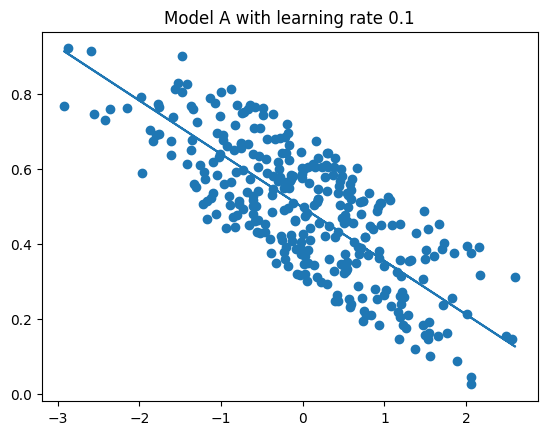

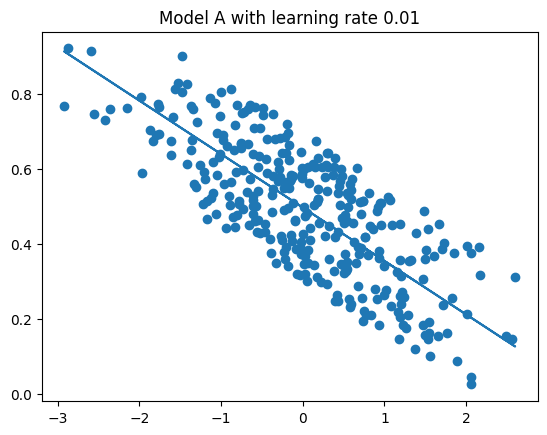

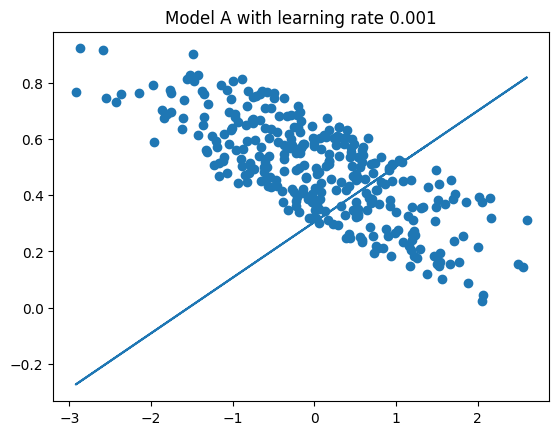

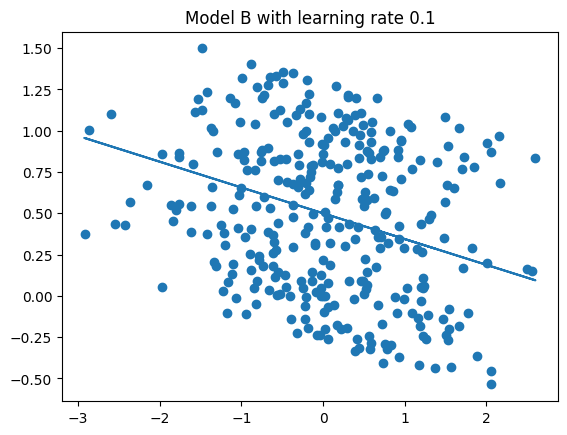

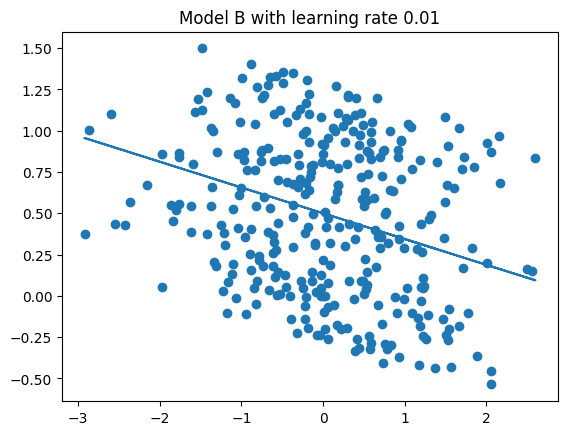

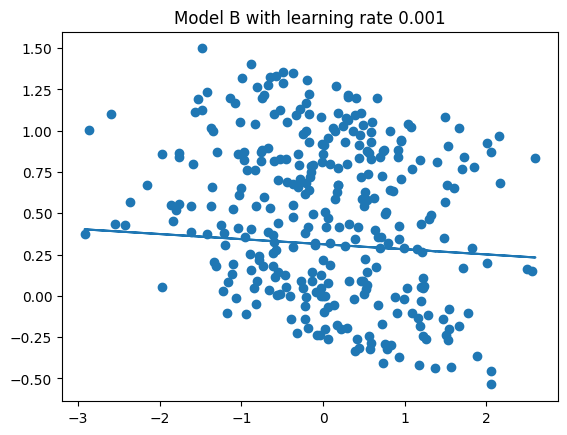

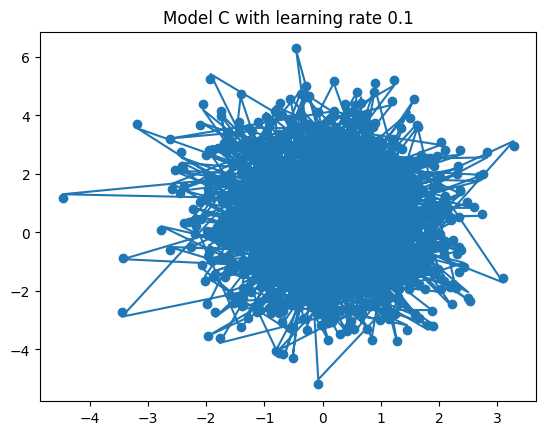

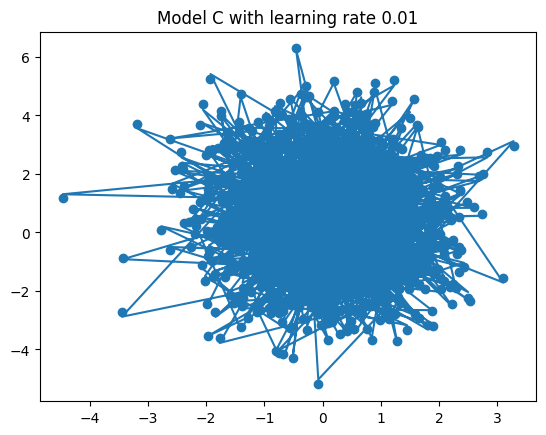

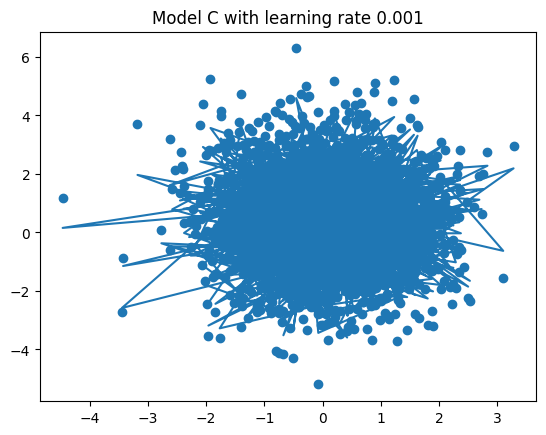

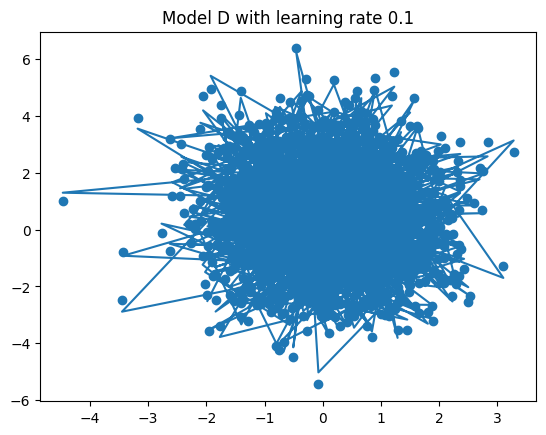

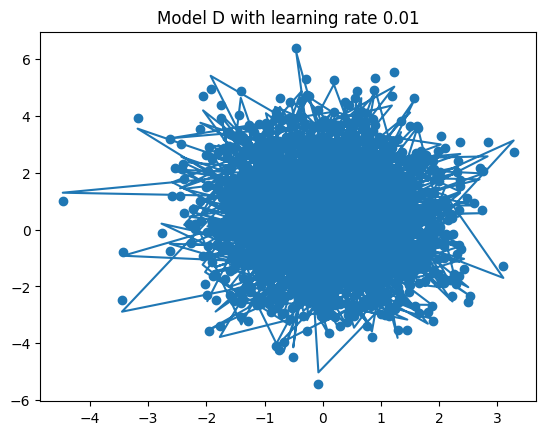

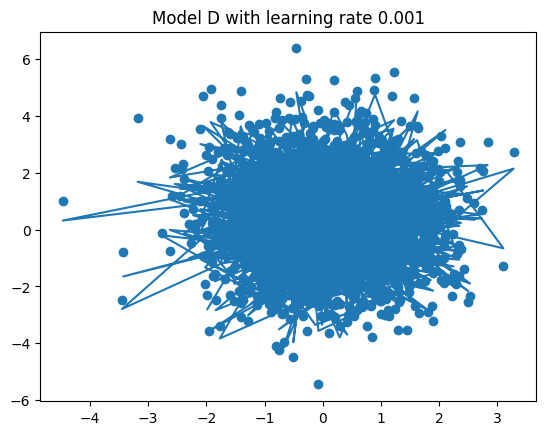

In [8]:
# Plot
for i, model in enumerate(models_A):
  plt.scatter(X_val_A[:,1],y_val_A)
  plt.plot(X_val_A[:,1],y_val_A_pred[i])
  plt.title("Model A with learning rate "+ str(learning_rates[i]))
  plt.show()
for i, model in enumerate(models_B):
  plt.scatter(X_val_B[:,1],y_val_B)
  plt.plot(X_val_B[:,1],y_val_B_pred[i])
  plt.title("Model B with learning rate "+ str(learning_rates[i]))
  plt.show()
for i, model in enumerate(models_C):
  plt.scatter(X_val_C[:,1],y_val_C)
  plt.plot(X_val_C[:,1],y_val_C_pred[i])
  plt.title("Model C with learning rate "+ str(learning_rates[i])) 
  plt.show()
for i, model in enumerate(models_D):
  plt.scatter(X_val_D[:,1],y_val_D)
  plt.plot(X_val_D[:,1],y_val_D_pred[i])
  plt.title("Model D with learning rate "+ str(learning_rates[i]))
  plt.show()
